In [10]:
## 1. Import Libraries and Load Cleaned Data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from module_function import KMeansClustering,ClusteringVisualizer
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [12]:
df = pd.read_csv('dataset/kc_house_data_CLEANING.csv.csv')
df.head(3)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062


In [13]:
## 2. Feature Scaling

In [14]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy="mean")),
    ('scaler',RobustScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas")
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__price,num__bedrooms,num__bathrooms,num__sqft_living,num__sqft_lot,num__floors,num__waterfront,num__view,num__condition,num__grade,num__sqft_above,num__sqft_basement,num__yr_built,num__yr_renovated,num__zipcode,num__lat,num__long,num__sqft_living15,num__sqft_lot15
0,-0.706083,0.0,-1.666667,-0.650045,-0.348442,-0.5,0.0,0.0,0.0,0.0,-0.372549,0.000000,-0.434783,0.0,1.329412,-0.292754,-0.133005,-0.574713,-0.395344
1,0.272404,0.0,0.000000,0.587711,-0.066572,0.5,0.0,0.0,0.0,0.0,0.598039,0.714286,-0.521739,1991.0,0.705882,0.720773,-0.438424,-0.172414,0.003813
2,-0.835784,-1.0,-1.666667,-1.015138,0.421742,-0.5,0.0,0.0,0.0,-1.0,-0.774510,0.000000,-0.913043,0.0,-0.435294,0.802415,-0.014778,1.011494,0.088702
3,0.476706,1.0,1.000000,0.044524,-0.463527,-0.5,0.0,0.0,2.0,0.0,-0.500000,1.625000,-0.217391,0.0,0.835294,-0.246377,-0.802956,-0.551724,-0.525788
4,0.185730,0.0,-0.333333,-0.204809,0.081799,-0.5,0.0,0.0,0.0,1.0,0.117647,0.000000,0.260870,0.0,0.105882,0.217391,0.911330,-0.045977,-0.023480


In [15]:
## 3. The Analysis K Selection in Kmean++

In [16]:
cluster_model = KMeansClustering(range_max=15, df_raw=df)
cluster_model.fit_model(X_cleaned)
cluster_model.compute_scores_dataframe()

[INFO] Model berhasil dilatih untuk semua rentang k.


,n_clusters(k),Inertia (WCSS),Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,Composite_Score
0,2,2.250255e+06,0.996142,3.348650e+07,0.009779,1.000000e+00
1,3,1.240398e+06,0.895540,3.038938e+07,0.390641,7.866430e-01
2,4,1.068883e+06,0.687613,2.350762e+07,0.624834,5.084280e-01
3,5,8.596748e+05,0.671987,2.191920e+07,0.620794,4.752893e-01
4,6,7.137570e+05,0.651055,2.112018e+07,0.778527,4.038578e-01
5,7,6.417110e+05,0.634329,1.957703e+07,0.827752,3.545795e-01
6,8,5.966492e+05,0.625464,1.804553e+07,0.806079,3.306413e-01
7,9,5.458908e+05,0.280941,1.725751e+07,0.978190,1.241157e-01
8,10,5.000251e+05,0.280498,1.674756e+07,0.895327,1.405855e-01
9,11,4.688481e+05,0.277357,1.607366e+07,0.884057,1.308959e-01


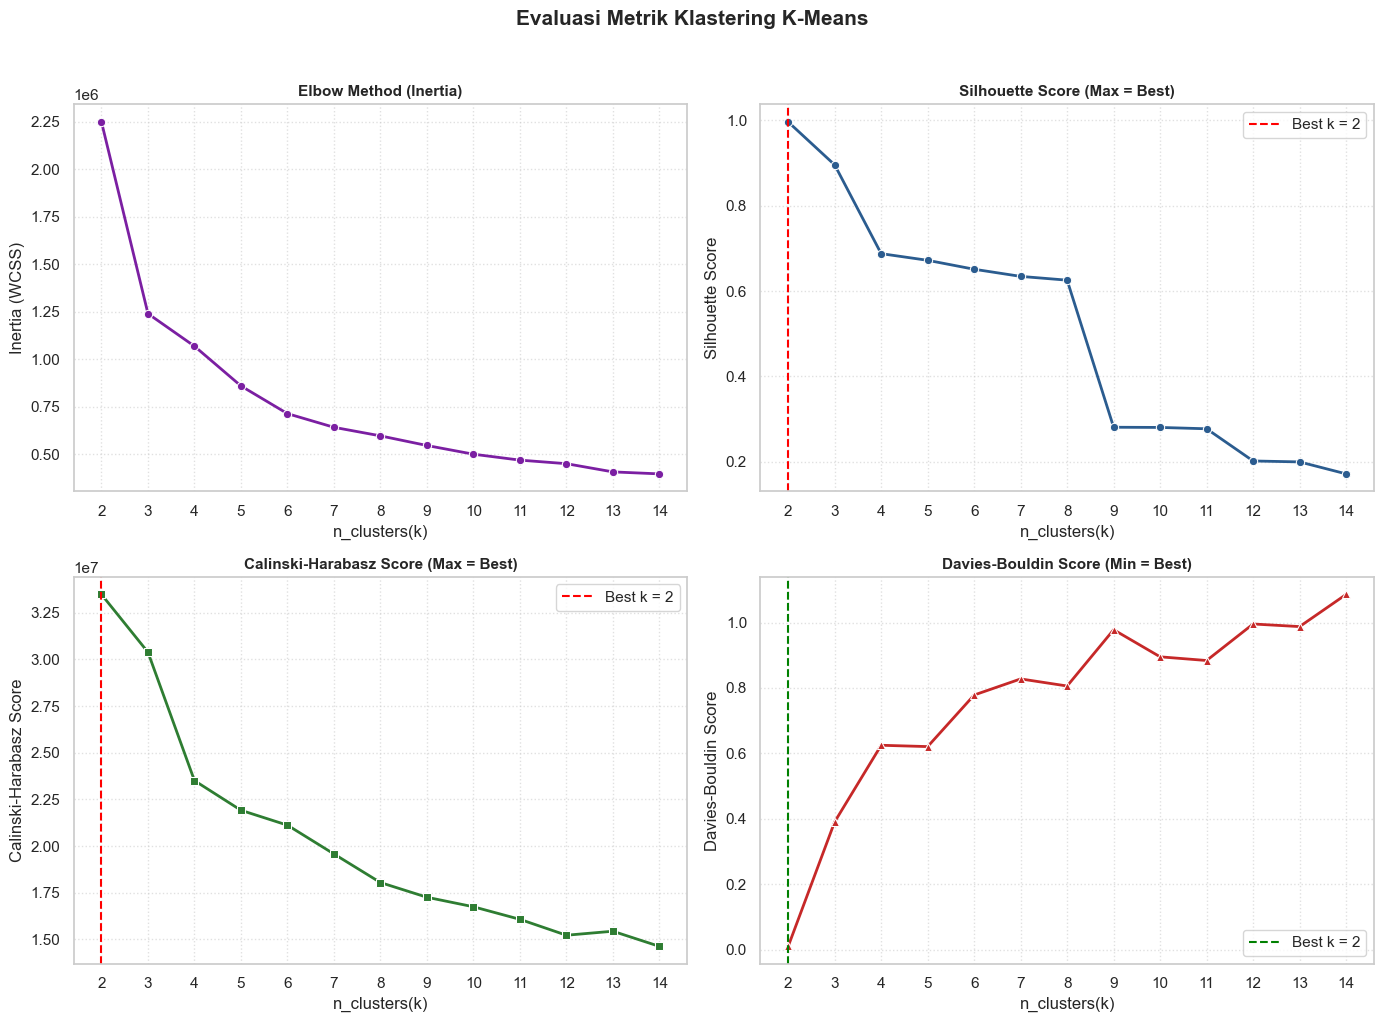

In [17]:
visualizer = ClusteringVisualizer(cluster_model)
visualizer.plot_evaluation_metrics()

[INFO] Model optimal dipilih dengan jumlah cluster (k) = 3


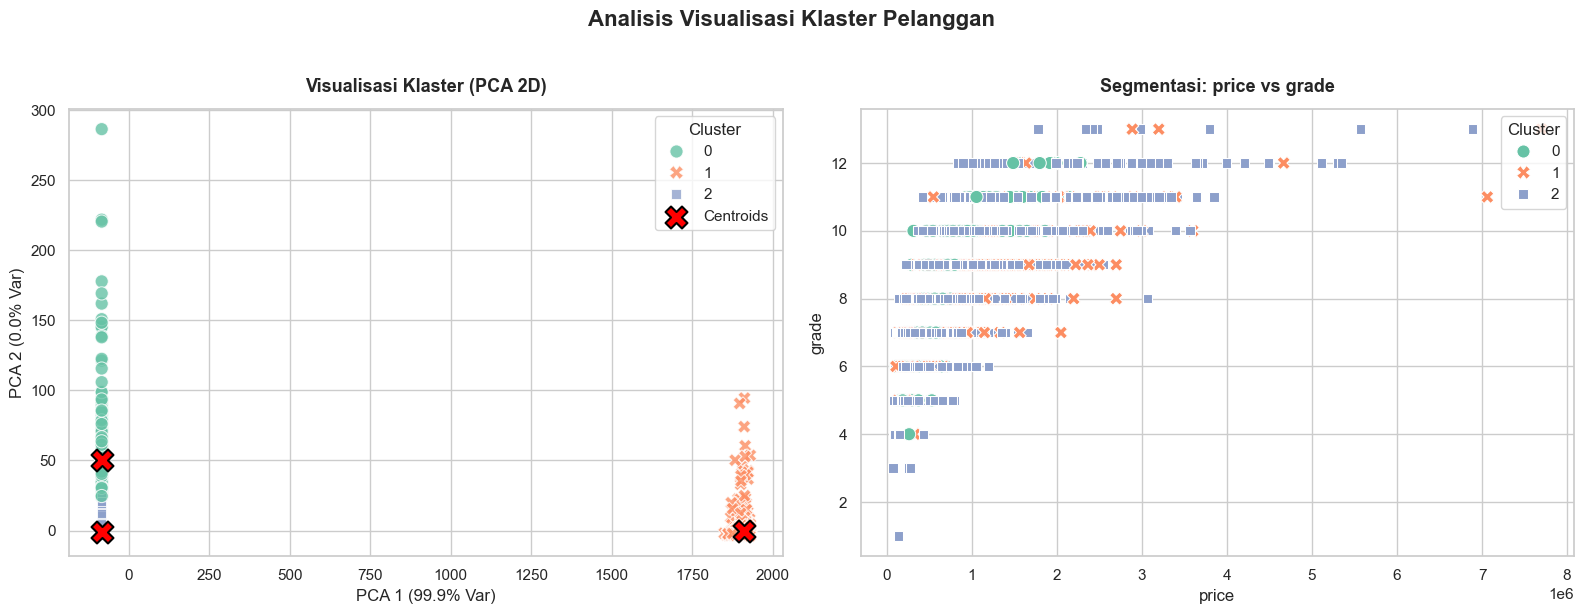

In [20]:
best_kmeans, df_clustered = cluster_model.fit_best_model(X_cleaned)
visualizer.plot_cluster_results(
    X_cleaned=X_cleaned, 
    best_kmeans=best_kmeans, 
    feature_x='price',   # Sesuaikan dengan nama kolom dataset Anda
    feature_y='grade' # Sesuaikan dengan nama kolom dataset Anda
)